# Less Fish, More Money: Canada's Commercial Sea Fisheries, 1990–2024

**COMP 6934 — Data Visualization · Course project code**

This notebook reproduces **every figure in the final report**. Run it top to bottom
(`Kernel → Restart & Run All`). Each figure is written to `../figures/` as a vector
PDF (included by the LaTeX report) and a PNG preview.

**Data**
* Fisheries and Oceans Canada (DFO), *Commercial Seafisheries Landings, 1990–2024*
  (Zonal Interchange File database, 2025) — `data/1990-2024 Commercial Seafisheries Landings EN.csv`
* Statistics Canada, Table 18-10-0005-01, *Consumer Price Index, annual average, all-items*
  (2002 = 100) — `data/cpi_canada_all_items.csv`, used to convert dollars to constant 2024 CAD.

**Research questions**
1. Has Canada's sea fishery grown or shrunk since 1990, and does the answer depend on
   whether we measure it in tonnes or in (inflation-adjusted) dollars?
2. What replaced the groundfish lost after the 1992 northern cod moratorium?
3. Is the growth in value driven by catching *more*, or by each kilogram being worth more?
4. How did these shifts play out across provinces, and what risks does the new
   structure create?

## 1. Setup

The next cell installs any missing libraries **into the Python environment this notebook is
running in** (whichever kernel you selected), so the notebook runs on any machine.

In [2]:
import importlib.util, subprocess, sys

REQUIRED = {"pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "scipy": "scipy"}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
print("Python:", sys.executable)
print("All required packages available.")

Installing: seaborn
Python: c:\python312\python.exe
All required packages available.


In [3]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "code" else Path.cwd()
DATA, FIGS = ROOT / "data", ROOT / "figures"
FIGS.mkdir(exist_ok=True)
LANDINGS_CSV = DATA / "1990-2024 Commercial Seafisheries Landings EN.csv"
CPI_CSV = DATA / "cpi_canada_all_items.csv"
BASE_YEAR = 2024          # all real dollars are constant 2024 CAD

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)
print("pandas", pd.__version__, "| seaborn", sns.__version__,
      "| matplotlib", mpl.__version__)

pandas 2.2.3 | seaborn 0.13.2 | matplotlib 3.10.1


### Visual style
One style is used for every figure so the report reads as a single system.

* Figures are drawn at their **final printed width** (6.5 in = the LaTeX text block
  at 1 in margins), so the 7–9 pt text inside them is never rescaled.
* **Colour follows the species group everywhere**: groundfish = blue, pelagics = aqua,
  shellfish = orange. These three hues were checked with a colour-vision-deficiency
  validator (all pairs pass; worst CVD ΔE = 9.2). The tiny "Other" group is neutral grey.
* Magnitude uses a single-hue (blue) sequential ramp; recessive hairline grids; no dual axes.

In [4]:
GROUPS = ["Groundfish", "Pelagics", "Shellfish", "Other"]
GROUP_COLOR = {"Groundfish": "#2a78d6", "Pelagics": "#1baf7a",
               "Shellfish": "#eb6834", "Other": "#b5b3ab"}
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, ACCENT_RED = "#e1e0d9", "#c3c2b7", "#e34948"
SEQ_BLUE = ["#f7fafe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
            "#256abf", "#184f95", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)
TEXT_WIDTH = 6.5

PROVINCES = ["Newfoundland and Labrador", "Nova Scotia", "New Brunswick",
             "Prince Edward Island", "Quebec", "British Columbia"]
PROV_ABBR = {"Newfoundland and Labrador": "NL", "Nova Scotia": "NS",
             "New Brunswick": "NB", "Prince Edward Island": "PE",
             "Quebec": "QC", "British Columbia": "BC"}
SPECIES_LABEL = {"Crab, Queen": "Snow crab", "Crab, Other": "Other crab",
                 "Redfish spp.": "Redfish"}
label = lambda s: SPECIES_LABEL.get(s, s)

sns.set_theme(context="paper", style="white", rc={
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9.5, "axes.titlesize": 10, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "axes.labelsize": 9, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.5, "grid.linestyle": "-",
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.major.size": 3, "ytick.major.size": 0,
    "xtick.major.width": 0.6, "xtick.bottom": True,
    "legend.fontsize": 8.5, "legend.frameon": False,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round",
    "text.color": INK, "axes.unicode_minus": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03, "pdf.fonttype": 42,
})

def save(fig, name, pad=0.04):
    """Write the vector PDF used by LaTeX and a 300-dpi PNG preview.

    The figure is resized until its tight bounding box (axes + every label and
    annotation) is exactly TEXT_WIDTH wide, so LaTeX places it at 100 % scale
    and every font prints at its nominal point size.
    """
    renderer = fig.canvas.get_renderer()
    for _ in range(6):
        bb = fig.get_tightbbox(renderer).padded(pad)
        excess = bb.width - TEXT_WIDTH
        if abs(excess) < 0.002:
            break
        w, h = fig.get_size_inches()
        fig.set_size_inches(w - excess, h)
    bb = fig.get_tightbbox(renderer).padded(pad)
    for ext in ("pdf", "png"):
        fig.savefig(FIGS / f"{name}.{ext}", bbox_inches=bb)
    print(f"saved figures/{name}.pdf  ({bb.width:.3f} x {bb.height:.3f} in)")

## 2. Load and clean the data

The DFO file is a "report-style" CSV. Cleaning rules:
* the last six lines are footnotes (source, "x = suppressed" etc.) — they are dropped;
* numbers are stored as text with thousands separators (`"22,450,009"`) — converted to numbers;
* `x` marks values **suppressed by DFO for confidentiality**. They become `NaN`, *never zero*,
  so they cannot silently deflate a total. DFO's own subtotal rows are complete, so group-level
  and national analyses are unaffected;
* nominal dollars are converted to **constant 2024 CAD** with the Statistics Canada CPI.

In [5]:
raw = pd.read_csv(LANDINGS_CSV, dtype=str)
print("raw shape:", raw.shape)
print("footnote lines dropped:")
print(raw[~raw["Year"].str.fullmatch(r"\d{4}", na=False)]["Year"].dropna().to_string())

df = (raw[raw["Year"].str.fullmatch(r"\d{4}", na=False)]
      .rename(columns={"Year": "year", "Province": "province", "Species Group": "group",
                       "Species": "species", "Quantity (kgs)": "kg", "Value (CAD)": "cad"}))
df["year"] = df["year"].astype(int)
suppressed = (df["cad"].str.strip() == "x")
for col in ["kg", "cad"]:
    df[col] = pd.to_numeric(df[col].str.replace(",", "").str.strip(), errors="coerce")

cpi = pd.read_csv(CPI_CSV).set_index("Year")["CPI_2002_100"]
df["cad_real"] = df["cad"] * df["year"].map(cpi[BASE_YEAR] / cpi)
df["is_total"] = df["species"].str.startswith("Total") | (df["species"] == "Grand total")
df = df.reset_index(drop=True)
print("\nclean shape:", df.shape, "| years", df.year.min(), "-", df.year.max())
print("suppressed ('x') cells:", suppressed.sum(), "of", len(df))
df.head()

raw shape: (10646, 6)
footnote lines dropped:
10641                             Quantity in live weight.
10642    "x" denotes data that is suppressed to meet co...
10643               Totals may not add up due to rounding.
10644        "Miscellaneous" quantity excludes seal pelts.
10645    Source: Department of Fisheries and Oceans (20...

clean shape: (10640, 8) | years 1990 - 2024
suppressed ('x') cells: 695 of 10640


,year,province,group,species,kg,cad,cad_real,is_total
0,1990,Atlantic,Shellfish,Clams / quahaug,"22,450,009.00","18,495,709.00","37,958,668.09",False
1,1990,Atlantic,Shellfish,"Crab, Other","864,815.00","321,713.00","660,250.28",False
2,1990,Atlantic,Shellfish,"Crab, Queen","26,177,016.00","49,576,647.00","101,745,950.28",False
3,1990,Atlantic,Shellfish,Lobster,"47,852,924.00","232,204,241.00","476,551,816.03",False
4,1990,Atlantic,Shellfish,Other shellfish,"9,121,513.00","8,450,173.00","17,342,255.56",False


In [6]:
# Where are the confidential suppressions? (only individual species in small provinces)
(df[df.cad.isna()].groupby(["province"]).size().rename("suppressed rows")
   .to_frame().assign(share_of_rows=lambda t: t["suppressed rows"] / (35 * 38)))

,suppressed rows,share_of_rows
province,,
New Brunswick,208,0.16
Newfoundland and Labrador,87,0.07
Nova Scotia,154,0.12
Prince Edward Island,78,0.06
Quebec,168,0.13


In [7]:
# The file's structure: 8 geographies x 38 species rows x 35 years
df.groupby("province").species.nunique().to_frame("species rows")

,species rows
province,
Atlantic,38
British Columbia,38
Canada,38
New Brunswick,38
Newfoundland and Labrador,38
Nova Scotia,38
Prince Edward Island,38
Quebec,38


### Consistency checks
Before plotting anything we verify the table is internally consistent, so the figures
can mix national, provincial and group-level rows safely.

In [8]:
tot = df[df.species.str.startswith("Total")]
gt  = df[df.species == "Grand total"].set_index(["year", "province"])

# 1) species-group subtotals add up to the grand total
diff1 = (tot.groupby(["year", "province"]).cad.sum() - gt.cad).abs() / gt.cad
# 2) Atlantic provinces add up to "Atlantic";  3) Atlantic + BC = Canada
g = df[df.species == "Grand total"].pivot(index="year", columns="province", values="cad")
diff2 = (g[PROVINCES[:5]].sum(axis=1) - g["Atlantic"]).abs() / g["Atlantic"]
diff3 = (g["Atlantic"] + g["British Columbia"] - g["Canada"]).abs() / g["Canada"]
# 4) CPI covers every year
assert set(df.year) <= set(cpi.index)
for name, d in [("groups -> grand total", diff1), ("provinces -> Atlantic", diff2),
                ("Atlantic + BC -> Canada", diff3)]:
    print(f"{name:<26} max relative difference = {d.max():.1e}")
    assert d.max() < 1e-5
print("All checks passed.")

groups -> grand total      max relative difference = 1.8e-07
provinces -> Atlantic      max relative difference = 2.1e-09
Atlantic + BC -> Canada    max relative difference = 6.2e-10
All checks passed.


### Helper tables

In [9]:
def species_table(province="Canada"):
    return df[(df.province == province) & ~df.is_total]

def group_totals(province="Canada"):
    return df[(df.province == province) & df.species.str.startswith("Total")]

nat = df[(df.province == "Canada") & (df.species == "Grand total")].set_index("year")
sp = species_table()
q_sp = sp.pivot(index="year", columns="species", values="kg") / 1e6          # kilotonnes
v_sp = sp.pivot(index="year", columns="species", values="cad_real") / 1e6    # 2024 $M
group_of = sp.drop_duplicates("species").set_index("species")["group"]

summary = pd.DataFrame({
    "volume (kt)": nat.kg / 1e6,
    "value, nominal ($B)": nat.cad / 1e9,
    "value, 2024 $B": nat.cad_real / 1e9,
    "real $ per kg": nat.cad_real / nat.kg,
})
summary.loc[[1990, 1992, 1995, 2000, 2010, 2019, 2020, 2021, 2022, 2024]]

,volume (kt),"value, nominal ($B)","value, 2024 $B",real $ per kg
year,,,,
1990,"1,621.09",1.43,2.93,1.81
1992,"1,312.28",1.39,2.66,2.03
1995,853.11,1.78,3.26,3.82
2000,"1,002.14",2.13,3.59,3.58
2010,951.53,1.83,2.52,2.65
2019,822.20,3.92,4.64,5.64
2020,752.65,2.88,3.39,4.50
2021,733.34,4.64,5.27,7.19
2022,686.73,4.73,5.03,7.33


## 3. Key statistics quoted in the report

In [10]:
chg = lambda a, b: 100 * (b / a - 1)
s = summary
print(f"Volume 1990 -> 2024:       {s.iloc[0,0]:,.0f} kt -> {s.iloc[-1,0]:,.0f} kt  ({chg(s.iloc[0,0], s.iloc[-1,0]):+.0f}%)")
print(f"Nominal value:             ${s.iloc[0,1]:.2f}B -> ${s.iloc[-1,1]:.2f}B ({chg(s.iloc[0,1], s.iloc[-1,1]):+.0f}%)")
print(f"Real value (2024 $):       ${s.iloc[0,2]:.2f}B -> ${s.iloc[-1,2]:.2f}B ({chg(s.iloc[0,2], s.iloc[-1,2]):+.0f}%)")
print(f"Real value per kg:         ${s.iloc[0,3]:.2f} -> ${s.iloc[-1,3]:.2f} (x{s.iloc[-1,3]/s.iloc[0,3]:.1f})")
print(f"Real value peak:           {s['value, 2024 $B'].idxmax()} (${s['value, 2024 $B'].max():.2f}B)")

# Long-run trend in volume (OLS on log volume) and in real value
yrs = s.index.values
for col in ["volume (kt)", "value, 2024 $B"]:
    r = stats.linregress(yrs, np.log(s[col]))
    print(f"Trend in {col:<15}: {100*(np.exp(r.slope)-1):+.2f}% per year  (R^2 = {r.rvalue**2:.2f}, p = {r.pvalue:.1e})")

conc = (v_sp[["Lobster", "Crab, Queen"]].sum(axis=1) / v_sp.sum(axis=1) * 100)
print("\nLobster + snow crab share of national landed value (%):")
print(conc.loc[[1990, 2000, 2010, 2019, 2024]].round(1).to_string())
hhi = ((v_sp.div(v_sp.sum(axis=1), axis=0)) ** 2).sum(axis=1) * 10_000
print(f"\nHerfindahl index of species value: {hhi[1990]:,.0f} (1990) -> {hhi[2024]:,.0f} (2024)")

print(f"\nCod volume: {q_sp.loc[1990,'Cod']:.0f} kt (1990) -> {q_sp.loc[1995,'Cod']:.1f} kt (1995) -> {q_sp.loc[2024,'Cod']:.1f} kt (2024)")

# Which species drive the year-to-year swings in national value?
# Var(total change) = sum_i Cov(change_i, total change), so each species' share is
# Cov(change_i, total) / Var(total); the shares add up to 1.
d = v_sp.diff().loc[1991:]
total_change = d.sum(axis=1)
var_share = d.apply(lambda c: np.cov(c, total_change)[0, 1]) / total_change.var()
print("\nShare of the variance in national year-to-year value changes:")
print((100 * var_share.sort_values(ascending=False).head(4)).round(1).rename(label).to_string())

Volume 1990 -> 2024:       1,621 kt -> 626 kt  (-61%)
Nominal value:             $1.43B -> $4.01B (+181%)
Real value (2024 $):       $2.93B -> $4.01B (+37%)
Real value per kg:         $1.81 -> $6.40 (x3.5)
Real value peak:           2021 ($5.27B)
Trend in volume (kt)    : -1.72% per year  (R^2 = 0.71, p = 1.9e-10)
Trend in value, 2024 $B : +1.26% per year  (R^2 = 0.39, p = 6.0e-05)

Lobster + snow crab share of national landed value (%):
year
1990   19.70
2000   48.20
2010   47.00
2019   64.20
2024   68.20

Herfindahl index of species value: 1,105 (1990) -> 2,896 (2024)

Cod volume: 402 kt (1990) -> 14.7 kt (1995) -> 17.8 kt (2024)

Share of the variance in national year-to-year value changes:
species
Snow crab   49.00
Lobster     36.10
Shrimp       3.30
Scallop      2.90


## 4. Figures

### Figure 1 — Line chart: volume vs value, indexed (1990 = 100)
**Point:** the fishery lands far less by weight but is worth more, even after inflation.
Indexing both measures to 1990 lets them share one y-axis (avoids a misleading dual axis).

saved figures/fig1_volume_vs_value.pdf  (6.499 x 2.483 in)


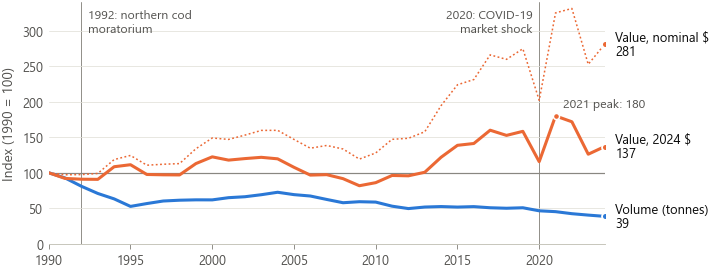

In [11]:
idx = lambda x: 100 * x / x.iloc[0]
lines = pd.DataFrame({"Volume (tonnes)": idx(nat.kg), "Value, 2024 $": idx(nat.cad_real),
                      "Value, nominal $": idx(nat.cad)})
long = lines.reset_index().melt("year", var_name="measure", value_name="index")
palette = {"Volume (tonnes)": GROUP_COLOR["Groundfish"], "Value, 2024 $": GROUP_COLOR["Shellfish"],
           "Value, nominal $": GROUP_COLOR["Shellfish"]}

fig, ax = plt.subplots(figsize=(TEXT_WIDTH, 2.85))
ax.axhline(100, color=MUTED, lw=0.8, zorder=1)
sns.lineplot(data=long, x="year", y="index", hue="measure", style="measure",
             palette=palette, dashes={"Volume (tonnes)": "", "Value, 2024 $": "",
                                      "Value, nominal $": (1.2, 1.6)},
             size="measure", sizes={"Volume (tonnes)": 2.0, "Value, 2024 $": 2.0,
                                    "Value, nominal $": 1.0},
             legend=False, ax=ax, zorder=3)
for col in lines:                                # direct end labels
    y = lines[col].iloc[-1]
    ax.plot(2024, y, "o", ms=4.5, color=palette[col], mec="white", mew=1.2, zorder=4)
    ax.annotate(f"{col}\n{y:.0f}", (2024, y), xytext=(7, 0), textcoords="offset points",
                va="center", fontsize=8.5, linespacing=1.15)
for yr, txt, dx, ha in [(1992, "1992: northern cod\nmoratorium", 0.4, "left"),
                        (2020, "2020: COVID-19\nmarket shock", -0.4, "right")]:
    ax.axvline(yr, color=MUTED, lw=0.6, zorder=0)
    ax.text(yr + dx, 330, txt, ha=ha, va="top", fontsize=8, color=INK_2, linespacing=1.15)
pk = lines["Value, 2024 $"].idxmax()
ax.plot(pk, lines["Value, 2024 $"][pk], "o", ms=4, color=GROUP_COLOR["Shellfish"], mec="white", mew=1, zorder=4)
ax.annotate(f"{pk} peak: {lines['Value, 2024 $'][pk]:.0f}", (pk, lines["Value, 2024 $"][pk]),
            xytext=(5, 4), textcoords="offset points", fontsize=8, color=INK_2, ha="left", va="bottom",
            annotation_clip=False)
ax.set(xlim=(1990, 2024), ylim=(0, 340), xlabel="", ylabel="Index (1990 = 100)",
       xticks=range(1990, 2025, 5))
ax.grid(axis="x", visible=False); ax.spines["left"].set_visible(False)
save(fig, "fig1_volume_vs_value"); plt.show()

### Figure 2 — Stacked area charts: composition by species group
**Point:** groundfish and pelagic volume collapsed; shellfish now carries most of the value.

saved figures/fig2_group_composition.pdf  (6.499 x 2.779 in)


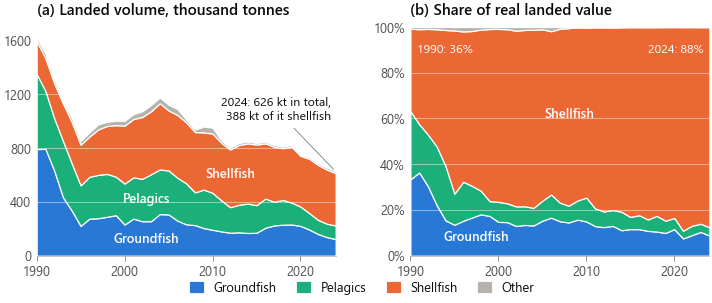

In [12]:
t = group_totals()
vol_g = t.pivot(index="year", columns="group", values="kg")[GROUPS] / 1e6
val_g = t.pivot(index="year", columns="group", values="cad_real")[GROUPS]
share_g = val_g.div(val_g.sum(axis=1), axis=0) * 100

def band_labels(ax, where):
    """Direct labels, placed where each band is thick enough to hold them."""
    for g, (x, y) in where.items():
        ax.text(x, y, g, ha="center", va="center", fontsize=8.5, color="white",
                fontweight="semibold")

fig, (a, b) = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.7), gridspec_kw=dict(wspace=0.25))
for ax, frame in [(a, vol_g), (b, share_g)]:
    ax.stackplot(frame.index, frame.T.values, colors=[GROUP_COLOR[g] for g in GROUPS],
                 edgecolor="white", linewidth=0.8)
    ax.set(xlim=(1990, 2024), xlabel="", xticks=[1990, 2000, 2010, 2020])
    ax.set_axisbelow(False); ax.grid(axis="x", visible=False)
    ax.grid(axis="y", color="white", lw=0.5, alpha=0.6); ax.spines["left"].set_visible(False)

band_labels(a, {"Groundfish": (2002.5, 125), "Pelagics": (2002.5, 420), "Shellfish": (2012, 610)})
a.set(ylim=(0, 1700), yticks=range(0, 1701, 400), title="(a) Landed volume, thousand tonnes")
a.annotate(f"2024: {vol_g.loc[2024].sum():.0f} kt in total,\n{vol_g.loc[2024,'Shellfish']:.0f} kt of it shellfish",
           (2024, vol_g.loc[2024].sum()), xytext=(-3, 34), textcoords="offset points", ha="right",
           fontsize=8, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.6))
band_labels(b, {"Groundfish": (1997.5, 8), "Shellfish": (2008, 62)})   # pelagics band too thin here; legend + panel (a) name it
for yr, xoff, ha in [(1990, 4, "left"), (2024, -4, "right")]:
    b.annotate(f"{yr}: {share_g.loc[yr, 'Shellfish']:.0f}%", (yr, 90), xytext=(xoff, 0),
               textcoords="offset points", ha=ha, va="center", fontsize=8, color="white")
b.set(ylim=(0, 100), title="(b) Share of real landed value")
b.yaxis.set_major_formatter(PercentFormatter(decimals=0))

handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUPS]
fig.legend(handles, GROUPS, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.06),
           handlelength=1.0, handleheight=0.9, columnspacing=1.6)
save(fig, "fig2_group_composition"); plt.show()

### Figure 3 — Heatmap: each species relative to its own peak
Each row is one species' landed volume as a % of its best year (1990–2024), so large and
small fisheries are comparable. Rows are ordered by the volume-weighted mean year of landings:
fisheries that faded early are at the top, fisheries that grew are at the bottom.
**Point:** the collapse was broader than cod, and the growth is concentrated in shellfish.

saved figures/fig3_species_heatmap.pdf  (6.501 x 3.874 in)


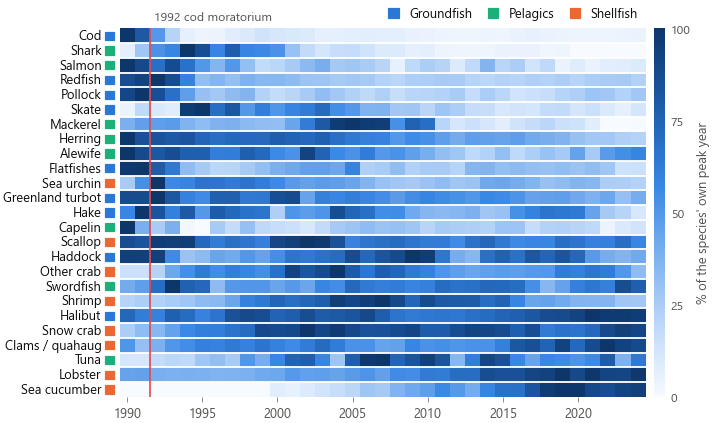

In [13]:
EXCLUDE = {"Miscellaneous", "Other shellfish", "Other groundfish", "Other pelagic/finfish",
           "Marine plants", "Elvers"}
q = q_sp.T[~q_sp.columns.isin(EXCLUDE)]
q = q[q.max(axis=1) >= 1.0]                        # fisheries that ever reached 1,000 t
rel = q.div(q.max(axis=1), axis=0) * 100
centre = (q * q.columns.values).sum(axis=1) / q.sum(axis=1)
rel = rel.loc[centre.sort_values().index]
rel.index = [label(s) for s in rel.index]

fig, ax = plt.subplots(figsize=(TEXT_WIDTH, 4.35))
sns.heatmap(rel, cmap=SEQ_CMAP, yticklabels=True, vmin=0, vmax=100, linewidths=0, ax=ax,
            cbar_kws=dict(fraction=0.025, pad=0.015, aspect=32, ticks=[0, 25, 50, 75, 100]))
for i in range(1, len(rel)):                     # white row gaps
    ax.axhline(i, color="white", lw=1.2)
ax.set(xlabel="", ylabel="")
years = list(rel.columns)
ax.set_xticks([years.index(y) + 0.5 for y in range(1990, 2025, 5)], range(1990, 2025, 5), rotation=0)
ax.tick_params(axis="y", length=0, pad=12, labelsize=8.5, labelcolor=INK)
ax.tick_params(axis="x", length=3, color=MUTED)
for i, name in enumerate(q.loc[centre.sort_values().index].index):   # group chips
    ax.add_patch(plt.Rectangle((-0.95, i + 0.22), 0.55, 0.56, color=GROUP_COLOR[group_of[name]],
                               clip_on=False))
x92 = years.index(1992)
ax.axvline(x92, color=ACCENT_RED, lw=1.1)
ax.text(x92 + 0.3, -0.35, "1992 cod moratorium", fontsize=8, color=INK_2, va="bottom")
cb = ax.collections[0].colorbar
cb.outline.set_visible(False); cb.ax.tick_params(labelsize=8, length=0)
cb.set_label("% of the species' own peak year", fontsize=8.5, color=INK_2)
handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUPS[:3]]
ax.legend(handles, GROUPS[:3], ncol=3, loc="lower right", bbox_to_anchor=(1.0, 1.0),
          handlelength=0.8, handleheight=0.8, columnspacing=1.2, borderaxespad=0.2)
save(fig, "fig3_species_heatmap"); plt.show()

### Figure 4 — Dumbbell chart: real landed value by species, 1990 vs 2024
**Point:** the winners and losers. Lobster and snow crab gained more than the entire value lost
by cod, salmon and herring.

saved figures/fig4_species_dumbbell.pdf  (6.499 x 3.064 in)


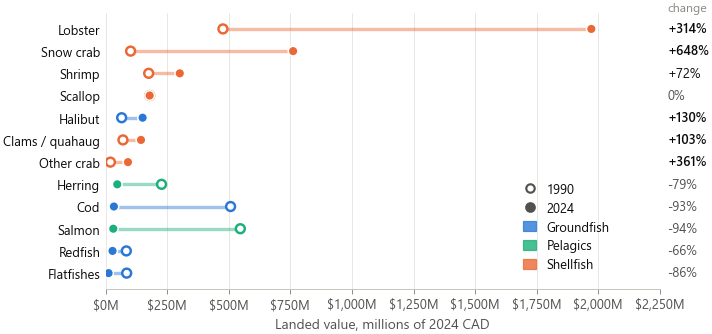

,1990,2024,change
species,,,
Flatfishes,86.00,12.00,-86.00
Redfish spp.,84.00,28.00,-66.00
Salmon,547.00,32.00,-94.00
Cod,508.00,34.00,-93.00
Herring,227.00,48.00,-79.00
"Crab, Other",20.00,91.00,361.00
Clams / quahaug,71.00,144.00,103.00
Halibut,65.00,151.00,130.00
Scallop,179.00,179.00,-0.00


In [14]:
top = pd.concat([v_sp.loc[1990], v_sp.loc[2024]], axis=1, keys=["1990", "2024"])
top = top[~top.index.str.startswith("Other")]
top = top[top.max(axis=1) >= 60].sort_values("2024")   # species worth >= $60M in either year
top["change"] = 100 * (top["2024"] / top["1990"] - 1)
top["color"] = [GROUP_COLOR[group_of[s]] for s in top.index]

fig, ax = plt.subplots(figsize=(TEXT_WIDTH, 3.25))
y = np.arange(len(top))
ax.hlines(y, top[["1990", "2024"]].min(axis=1), top[["1990", "2024"]].max(axis=1),
          color=top["color"], lw=2.2, alpha=0.45, zorder=2)
sns.scatterplot(x=top["1990"], y=y, ax=ax, s=34, facecolor="white", edgecolor=top["color"],
                linewidth=1.6, zorder=3, legend=False)
sns.scatterplot(x=top["2024"], y=y, ax=ax, s=40, color=top["color"], edgecolor="white",
                linewidth=1.0, zorder=4, legend=False)
ax.set_yticks(y, [label(s) for s in top.index])
ax.tick_params(axis="y", labelcolor=INK, labelsize=8.5)
xmax = 2250
for yi, (name, r) in enumerate(top.iterrows()):
    ax.text(xmax + 30, yi, f"{round(r['change']):+d}%" if round(r["change"]) else "0%", va="center", ha="left", fontsize=8.5,
            color=INK if r["change"] >= 0 else INK_2, fontweight="semibold" if abs(r["change"]) > 100 else "normal")
ax.text(xmax + 30, len(top) - 0.35, "change", fontsize=8, color=MUTED, va="bottom")
ax.set(xlim=(0, xmax), ylim=(-0.7, len(top) - 0.3), xlabel="Landed value, millions of 2024 CAD", ylabel="")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}M"))
ax.grid(axis="y", visible=False); ax.spines["left"].set_visible(False)
from matplotlib.lines import Line2D
leg = [Line2D([], [], marker="o", ls="", mfc="white", mec=INK_2, mew=1.4, ms=5.5, label="1990"),
       Line2D([], [], marker="o", ls="", color=INK_2, ms=6, label="2024")]
leg += [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g], alpha=0.8, label=g) for g in GROUPS[:3]]
ax.legend(handles=leg, loc="lower right", bbox_to_anchor=(0.93, 0.02), ncol=1, handlelength=1.0,
          handleheight=0.8, labelspacing=0.45)
save(fig, "fig4_species_dumbbell"); plt.show()
top[["1990", "2024", "change"]].round(0)

### Figure 5 — Connected scatter plots: quantity vs real price per kg
Each point is one year; the path connects consecutive years and the points darken with time
(grey ramp, so time is never confused with a species-group colour).
**Point:** lobster grew on *both* axes (more tonnes and a higher price); snow crab's value is
driven mostly by volatile prices; cod never recovered its volume.

saved figures/fig5_price_quantity.pdf  (6.487 x 4.383 in)


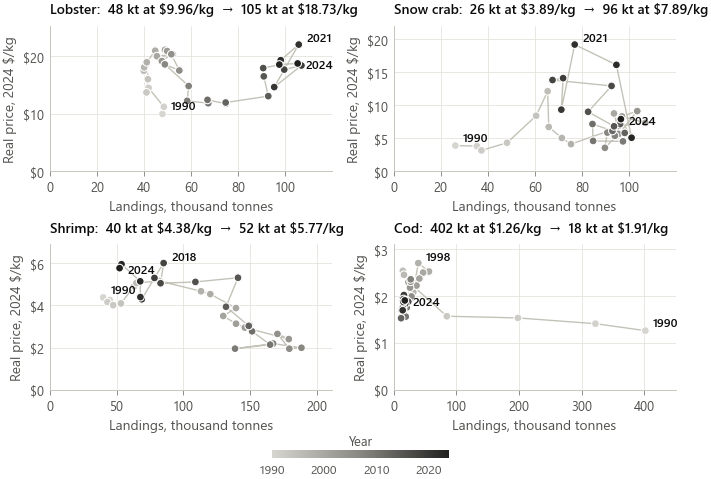

In [15]:
price = v_sp / q_sp                                   # real $ per kg (2024 CAD)
panels = ["Lobster", "Crab, Queen", "Shrimp", "Cod"]
fig, axes = plt.subplots(2, 2, figsize=(TEXT_WIDTH, 4.3), gridspec_kw=dict(hspace=0.5, wspace=0.22))
norm = mpl.colors.Normalize(1990, 2024)
# Time uses a neutral grey ramp so it is never confused with a species-group hue.
year_cmap = LinearSegmentedColormap.from_list("yrs", ["#d6d5cf", "#898781", "#1f1f1e"])
for ax, s in zip(axes.flat, panels):
    d = pd.DataFrame({"kt": q_sp[s], "price": price[s]}).reset_index()
    ax.plot(d.kt, d.price, color=AXIS, lw=0.9, zorder=1)
    sns.scatterplot(data=d, x="kt", y="price", hue="year", palette=year_cmap, hue_norm=norm,
                    s=26, edgecolor="white", linewidth=0.7, legend=False, ax=ax, zorder=2)
    for yr, off, ha in [(1990, (5, 3), "left"), (2024, (5, -3), "left"),
                        (int(d.loc[d.price.idxmax(), "year"]), (5, 2), "left")]:
        r = d[d.year == yr].iloc[0]
        ax.annotate(str(yr), (r.kt, r.price), xytext=off, textcoords="offset points",
                    fontsize=8, color=INK, ha=ha, fontweight="semibold")
    r0, r1 = d.iloc[0], d.iloc[-1]
    ax.set_title(f"{label(s)}:  {r0.kt:.0f} kt at \\${r0.price:.2f}/kg  \u2192  {r1.kt:.0f} kt at \\${r1.price:.2f}/kg",
                 fontsize=9, fontweight="semibold")
    ax.set(xlabel="Landings, thousand tonnes", ylabel="Real price, 2024 $/kg")
    ax.set_ylim(0, d.price.max() * 1.15); ax.set_xlim(0, d.kt.max() * 1.12)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:.0f}"))
    ax.grid(axis="x", visible=True)
cax = fig.add_axes([0.40, -0.035, 0.22, 0.018])
cb = fig.colorbar(mpl.cm.ScalarMappable(norm, year_cmap), cax=cax, orientation="horizontal",
                  ticks=[1990, 2000, 2010, 2020])
cb.outline.set_visible(False); cb.ax.tick_params(labelsize=8, length=0)
cax.set_title("Year", fontsize=8.5, color=INK_2, loc="center", pad=3, fontweight="normal")
save(fig, "fig5_price_quantity"); plt.show()

### Figure 6 — 100 % stacked bar chart: provincial value by species group, 1990 vs 2024
**Point:** every Atlantic province converged on shellfish; Newfoundland and Labrador's
transformation (groundfish 62% → 12%) is the most extreme. BC moved from salmon (pelagics) to shellfish.

saved figures/fig6_provinces.pdf  (6.499 x 3.313 in)


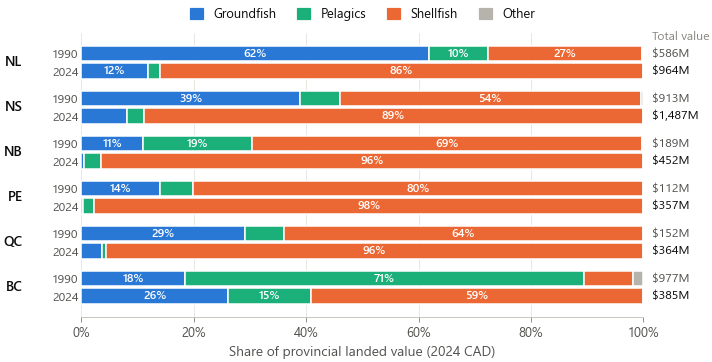

group                           Groundfish  Pelagics  Shellfish  Other  total ($M 2024)
province                  year                                                         
British Columbia          1990       18.00     71.00       9.00   2.00           977.00
                          2024       26.00     15.00      59.00   0.00           385.00
New Brunswick             1990       11.00     19.00      69.00   0.00           189.00
                          2024        1.00      3.00      96.00   0.00           452.00
Newfoundland and Labrador 1990       62.00     10.00      27.00   0.00           586.00
                          2024       12.00      2.00      86.00   0.00           964.00
Nova Scotia               1990       39.00      7.00      54.00   0.00           913.00
                          2024        8.00      3.00      89.00   0.00         1,487.00
Prince Edward Island      1990       14.00      6.00      80.00   0.00           112.00
                          2024        0.00      2.00      98.00   0.00           357.00
Quebec                    1990       29.00      7.00      64.00   0.00           152.00
                          2024        4.00      1.00      96.00   0.00           364.00

In [16]:
pt = df[df.species.str.startswith("Total") & df.province.isin(PROVINCES) & df.year.isin([1990, 2024])]
val = pt.pivot_table(index=["province", "year"], columns="group", values="cad_real")[GROUPS]
shr = val.div(val.sum(axis=1), axis=0) * 100
tot_real = val.sum(axis=1) / 1e6

fig, ax = plt.subplots(figsize=(TEXT_WIDTH, 3.35))
ypos, labels = [], []
for i, p in enumerate(PROVINCES):
    for j, yr in enumerate([1990, 2024]):
        yp = i * 2.7 + j * 1.05
        left = 0
        for g in GROUPS:
            w = shr.loc[(p, yr), g]
            ax.barh(yp, w, left=left, height=0.92, color=GROUP_COLOR[g], edgecolor="white", linewidth=1.0)
            if w >= 9:
                ax.text(left + w / 2, yp, f"{w:.0f}%", ha="center", va="center", fontsize=7.8,
                        color="white", fontweight="semibold")
            left += w
        ax.text(101.5, yp, f"${tot_real[(p, yr)]:,.0f}M", va="center", fontsize=8,
                color=INK if yr == 2024 else INK_2)
        ypos.append(yp); labels.append(str(yr))
    ax.text(-10.5, i * 2.7 + 0.525, PROV_ABBR[p], ha="right", va="center", fontsize=9,
            fontweight="semibold", color=INK)
ax.set_yticks(ypos, labels); ax.tick_params(axis="y", labelsize=8, labelcolor=INK_2, pad=2)
ax.invert_yaxis()
ax.set(xlim=(0, 100), xlabel="Share of provincial landed value (2024 CAD)")
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False); ax.spines["left"].set_visible(False)
ax.text(101.5, -1.0, "Total value", fontsize=8, color=MUTED, va="center")
handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUPS]
ax.legend(handles, GROUPS, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 1.0),
          handlelength=1.0, handleheight=0.9, columnspacing=1.6)
save(fig, "fig6_provinces"); plt.show()
shr.round(0).assign(**{"total ($M 2024)": tot_real.round(0)})

### Figure 7 — Box plot: year-to-year volatility of real landed value
Distribution of the annual % change in real landed value, 1991–2024, for the ten most valuable
species of 2024. **Point:** lobster is a steady anchor, but snow crab — the second pillar of
the new fishery — is by far the most volatile species, and it drives the national swings.

saved figures/fig7_volatility.pdf  (6.501 x 2.926 in)


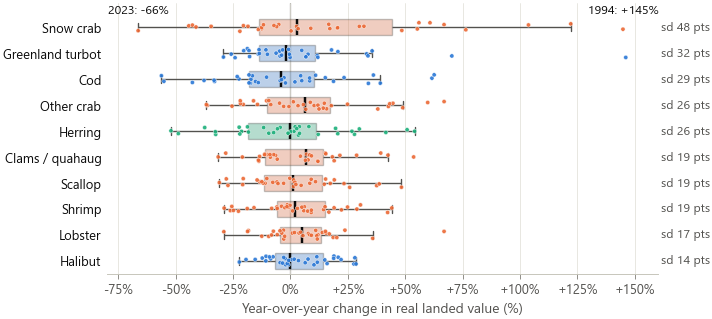

,mean,50%,std,min,max
species,,,,,
"Crab, Queen",15.50,3.00,48.50,-66.30,144.80
Greenland turbot,4.90,-2.10,32.40,-29.20,146.10
Cod,-3.40,-4.20,28.90,-56.20,62.60
"Crab, Other",7.70,6.20,26.50,-36.60,66.90
Herring,-1.10,-0.30,25.70,-52.00,54.10
Clams / quahaug,3.80,6.70,19.50,-31.50,53.70
Scallop,1.70,1.30,19.20,-31.00,48.40
Shrimp,3.30,2.00,18.90,-28.90,44.20
Lobster,5.50,5.00,17.20,-29.00,66.90


In [17]:
yoy = v_sp.pct_change(fill_method=None).mul(100).loc[1991:]
keep = v_sp.loc[2024].drop([c for c in v_sp.columns if c.startswith("Other")]).nlargest(10).index
long = yoy[keep].melt(ignore_index=False, var_name="species", value_name="pct").reset_index().dropna()
order = yoy[keep].std().sort_values(ascending=False).index
long["species_lbl"] = long.species.map(label)
pal = {label(s): GROUP_COLOR[group_of[s]] for s in keep}

fig, ax = plt.subplots(figsize=(TEXT_WIDTH, 3.2))
ax.axvline(0, color=MUTED, lw=0.8, zorder=0)
sns.boxplot(data=long, y="species_lbl", x="pct", hue="species_lbl", order=[label(s) for s in order],
            palette=pal, legend=False, width=0.62, fliersize=0, linewidth=0.9, ax=ax,
            boxprops=dict(alpha=0.35, edgecolor=INK_2), whiskerprops=dict(color=INK_2),
            capprops=dict(color=INK_2), medianprops=dict(color=INK, linewidth=1.6))
sns.stripplot(data=long, y="species_lbl", x="pct", hue="species_lbl", order=[label(s) for s in order],
              palette=pal, legend=False, size=2.8, jitter=0.18, alpha=0.9, ax=ax, zorder=3,
              edgecolor="white", linewidth=0.3)
for i, s in enumerate(order):
    ax.text(1.005, i, f"sd {yoy[s].std():.0f} pts", transform=ax.get_yaxis_transform(),
            va="center", fontsize=8, color=INK_2)
crab = long[long.species == "Crab, Queen"]
for r in [crab.loc[crab.pct.idxmin()], crab.loc[crab.pct.idxmax()]]:
    ax.annotate(f"{int(r.year)}: {r.pct:+.0f}%", (r.pct, 0), xytext=(0, 7),
                textcoords="offset points", fontsize=8, color=INK, ha="center", va="bottom")
ax.set_ylim(len(order) - 0.5, -0.95)
ax.set(xlabel="Year-over-year change in real landed value (%)", ylabel="", xlim=(-80, 160),
       xticks=range(-75, 151, 25))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.0f}%" if v else "0%"))
ax.tick_params(axis="y", labelcolor=INK, labelsize=8.5)
ax.grid(axis="y", visible=False); ax.spines["left"].set_visible(False)
save(fig, "fig7_volatility"); plt.show()
yoy[order].describe().T[["mean", "50%", "std", "min", "max"]].round(1)

## 5. Summary
All seven figures in `../figures/` are regenerated by this notebook. The numbers printed in
Section 3 and under each figure are the ones quoted in the report text.